# **Data Cleaning**
----

<br/>

### **Definition**
---

- Data Cleaning is the process of preparing data for Analysis/ ML / DL by removing or modifying data that is
incorrect, incomplete, irrelevent, duplicated, or improperly formatted.

<br/>

### **Some Important Steps**
---

- Handling Missing Data.
- Outlier Detection and Handling.
- Data Scaling and Transformation.
- Encoding Categorical Variables.
- Handling Duplicates.
- Dealing with Incosistent Data.

<br/>

### **Importing Neccessary Libraries**
---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Messy Data**
---

In [2]:
loan_df = pd.read_csv("./loan_data_set.csv")

loan_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


<br/>

#### **Data Before-Cleaning**
---

In [3]:
# --- No. of Rows and Columns (Shape of Dataset)
size_BC = loan_df.shape

In [4]:
# --- Null values (returns Postions)
null_values_BC = loan_df.isnull()

In [5]:
# --- Total Null-Values in each Column
loan_df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
# --- Percentage of Null-values in each Column
(loan_df.isnull().sum()/loan_df.shape[0]) * 100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [35]:
# --- Total Null-values in dataset
total_null_values = loan_df.isnull().sum().sum()

# --- Percentage of Null-values in dataset
total_percent_null_values = (loan_df.isnull().sum().sum() / loan_df.shape[0]) * 100

print(
    f" -> Total Null-values:  {round(total_null_values,4)}\n"
    f" -> Percent Null-values:  {round(total_percent_null_values,4)} %\n"
)

 -> Total Null-values:  149
 -> Percent Null-values:  24.2671 %



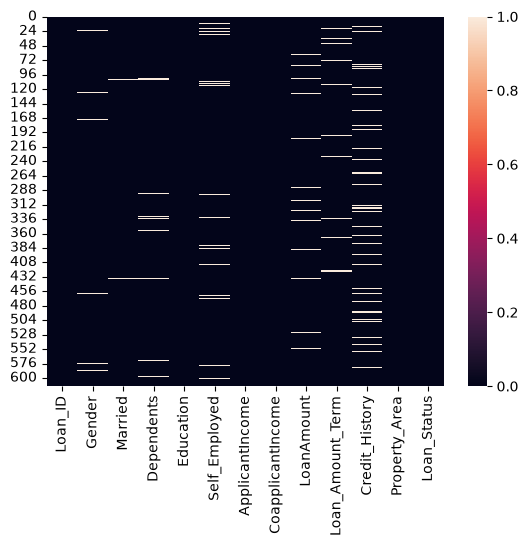

In [34]:
sns.heatmap(loan_df.isnull())
plt.show()

<br/>

#### **Removing Data**
---

In [24]:
# --- Creating a new dataset-copy for removing (to just see difference)
removing_loan_df = loan_df.copy(deep=True)

removing_loan_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [25]:
# --- Delete any Columns
removing_loan_df.drop(columns=["Credit_History"], inplace=True)  # inplace=True --> when want to change existent dataset not to create new

In [26]:
# --- Delete Null-values
removing_loan_df.dropna(inplace=True)
removing_loan_df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Property_Area        0
Loan_Status          0
dtype: int64

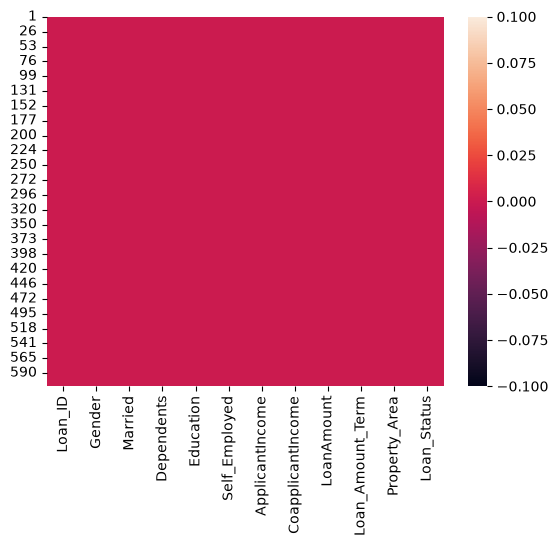

In [27]:
sns.heatmap(removing_loan_df.isnull())
plt.show()

<br/>

#### **Missing Values**
---

In [28]:
# --- Creating a new dataset-copy for missing values (to just see difference)
missing_values_loan_df = loan_df.copy(deep=True)

missing_values_loan_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [29]:
# --- No. of Missing values in each Column
missing_values_loan_df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [38]:
# --- Filling Null-values
missing_values_loan_df.fillna({"Gender": missing_values_loan_df["Gender"].mode()[0]}, inplace=True)
null_values_gender = missing_values_loan_df["Gender"].isnull().sum()
print(f" --> Gender Null-values:  {null_values_gender}")

 --> Gender Null-values:  0
